In [6]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import PerfectSeparationError
import liwc as liwc_lexicon

from pathlib import Path


# ----- 1. Load LIWC-processed data -----
# Run src/liwc_script.py first, then point this to its output pickle.
PROCESSED_PICKLE_PATH = "../reddit/liwc/drug_subreddit_pred_merge.fullframe.pickle"
LABEL_COLUMN = "final_label"

df = pd.read_pickle(PROCESSED_PICKLE_PATH)

# LIWC columns created by liwc_script.py: core LIWC + custom categories.
# Keep only categories that are not already in core LIWC keys to avoid duplicates.
custom_liwc_columns = ["POLITICAL", "PURPOSE", "ORDER", "JUSTICE"]
expected_liwc_columns = liwc_lexicon.liwc_keys + custom_liwc_columns
liwc_features = [c for c in expected_liwc_columns if c in df.columns]

if not liwc_features:
    raise ValueError(
        "No LIWC feature columns found. Ensure src/liwc_script.py was run and the correct pickle is loaded."
    )
if LABEL_COLUMN not in df.columns:
    raise ValueError(f"Label column '{LABEL_COLUMN}' not found in dataframe columns.")

# ----- 2. Prepare Features and Outcome -----
analysis_df = df[liwc_features + [LABEL_COLUMN]].copy()
analysis_df = analysis_df.dropna(subset=[LABEL_COLUMN])
X = analysis_df[liwc_features].apply(pd.to_numeric, errors="coerce").fillna(0.0)
y = pd.to_numeric(analysis_df[LABEL_COLUMN], errors="coerce")
valid = y.notna()
X = X.loc[valid]
y = y.loc[valid]

# Drop zero-variance columns to reduce singularity risk in Logit.
std = X.std(axis=0)
X = X.loc[:, std > 0]

if y.nunique() < 2:
    raise ValueError("Label column must contain at least two classes for logistic regression.")

print(f"Loaded rows for DLA: {len(X)}")
print(f"Number of LIWC features after filtering: {X.shape[1]}")

# ----- 3. Fit models in next cell -----
# Cell 1 performs robust logistic fitting (and writes `logit_results`).

Loaded rows for DLA: 20000
Number of LIWC features after filtering: 77


In [7]:
# --- Primary path: L2-regularized logistic regression (interpretable, stable) ---
# Regularization is required here because the LIWC feature set contains
# hierarchical / sum-redundant categories (e.g. PRONOUN >= PPRON + IPRON), which
# causes the unregularized MLE to wander to large magnitudes and fail to
# converge. We therefore make L2-regularized logistic regression the primary
# fit, choose the penalty by 5-fold CV on log-loss, and use a percentile
# bootstrap for 95% CIs and a non-parametric pseudo p-value (regularized MLEs
# do not have valid Wald p-values).

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

# 1) Standardize LIWC predictors (sklearn handles the intercept separately).
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=X.columns,
)

# 2) Pick L2 strength by 5-fold CV on log-loss.
#    class_weight="balanced" reweights the minority class to reduce the
#    pull toward the majority that we saw in the unregularized fit.
cv_grid = np.logspace(-3, 3, 13)  # C = 1 / alpha
cv_model = LogisticRegressionCV(
    Cs=cv_grid,
    cv=5,
    l1_ratios=[0],
    solver="lbfgs",
    scoring="neg_log_loss",
    class_weight="balanced",
    max_iter=2000,
    n_jobs=-1,
    refit=True,
    random_state=42,
)
cv_model.fit(X_scaled.values, y.values)
best_C = float(cv_model.C_[0])

# 3) Percentile bootstrap for 95% CIs and pseudo p-values.
N_BOOT = 200
rng = np.random.default_rng(42)
n = len(y)
n_features = X_scaled.shape[1]
boot_coefs = np.zeros((N_BOOT, n_features + 1))  # +1 for intercept
X_arr = X_scaled.values
y_arr = y.values
for b in range(N_BOOT):
    idx = rng.integers(0, n, size=n)
    mb = LogisticRegression(
        C=best_C,
        l1_ratio=0,
        solver="lbfgs",
        class_weight="balanced",
        max_iter=2000,
    ).fit(X_arr[idx], y_arr[idx])
    boot_coefs[b, 0] = mb.intercept_[0]
    boot_coefs[b, 1:] = mb.coef_.ravel()

ci_low = np.percentile(boot_coefs, 2.5, axis=0)
ci_high = np.percentile(boot_coefs, 97.5, axis=0)
# Two-sided fraction of bootstrap replicates crossing zero.
p_boot = 2.0 * np.minimum(
    (boot_coefs <= 0).mean(axis=0),
    (boot_coefs >= 0).mean(axis=0),
)

# 4) Build the results table used by downstream diagnostics/plot cells.
feature_names = ["const"] + list(X_scaled.columns)
coef = np.concatenate([[float(cv_model.intercept_[0])], cv_model.coef_.ravel()])

logit_results = pd.DataFrame({
    "LIWC_feature": feature_names,
    "coef_logit": coef,
    "ci_low": ci_low,
    "ci_high": ci_high,
    "p_value_logit": p_boot,
}).sort_values("coef_logit", ascending=False)

used_path = f"l2_regularized_sklearn_balanced_C={best_C:.4g}"
nz_total = int((np.abs(logit_results["coef_logit"].values) > 1e-9).sum())
nz_no_const = int(
    (np.abs(logit_results.loc[logit_results["LIWC_feature"] != "const", "coef_logit"].values) > 1e-9).sum()
)

print("Path used:", used_path)
print("Selected C (1/alpha):", best_C)
print("Bootstrap replicates:", N_BOOT)
print("Total params:", len(logit_results))
print("Non-zero params (incl const):", nz_total)
print("Non-zero params (excl const):", nz_no_const)
print(logit_results.head(10))

/opt/miniconda3/envs/research-proj/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Path used: l2_regularized_sklearn_balanced_C=0.1
Selected C (1/alpha): 0.1
Bootstrap replicates: 200
Total params: 78
Non-zero params (incl const): 78
Non-zero params (excl const): 77
   LIWC_feature  coef_logit    ci_low   ci_high  p_value_logit
64       SOCIAL    1.133817  0.883367  1.431076           0.00
15      COGPROC    0.786575  0.504500  1.130788           0.00
45       NEGEMO    0.573534  0.349719  0.820684           0.00
31       HEALTH    0.518308  0.362318  0.697488           0.00
39        IPRON    0.375324  0.230804  0.528621           0.00
63        SHEHE    0.363977  0.119602  0.662497           0.04
66        SWEAR    0.362929  0.142115  0.533497           0.00
0         const    0.330009  0.298007  0.406856           0.00
44       NEGATE    0.249888  0.165739  0.324565           0.00
62       SEXUAL    0.247822  0.139759  0.330528           0.00


In [8]:
# --- Quick diagnostics (single consolidated cell) ---
print("X shape:", X.shape)
print("Columns in X:", list(X.columns)[:10], "...", len(X.columns))
print("y distribution:\n", y.value_counts(dropna=False))
print("y mean:", float(y.mean()))
print("logit_results rows:", len(logit_results))
print("coef summary:\n", logit_results["coef_logit"].describe())
print("non-zero count:", int((logit_results["coef_logit"].abs() > 1e-9).sum()))
print("Top +coef:\n", logit_results.head(5))
print("Top -coef:\n", logit_results.tail(5))

X shape: (20000, 77)
Columns in X: ['ACHIEV', 'ADJ', 'ADVERB', 'AFFECT', 'AFFILIATION', 'ANGER', 'ANX', 'ARTICLE', 'ASSENT', 'AUXVERB'] ... 77
y distribution:
 final_label
1    12828
0     7172
Name: count, dtype: int64
y mean: 0.6414
logit_results rows: 78
coef summary:
 count    78.000000
mean      0.033257
std       0.254337
min      -0.635767
25%      -0.109258
50%       0.020161
75%       0.133103
max       1.133817
Name: coef_logit, dtype: float64
non-zero count: 78
Top +coef:
    LIWC_feature  coef_logit    ci_low   ci_high  p_value_logit
64       SOCIAL    1.133817  0.883367  1.431076            0.0
15      COGPROC    0.786575  0.504500  1.130788            0.0
45       NEGEMO    0.573534  0.349719  0.820684            0.0
31       HEALTH    0.518308  0.362318  0.697488            0.0
39        IPRON    0.375324  0.230804  0.528621            0.0
Top -coef:
     LIWC_feature  coef_logit    ci_low   ci_high  p_value_logit
34             I   -0.297494 -0.460150 -0.163725         

/var/folders/ns/p84w9tpx2y35z79cb9pml23m0000gn/T/ipykernel_19674/1299154780.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


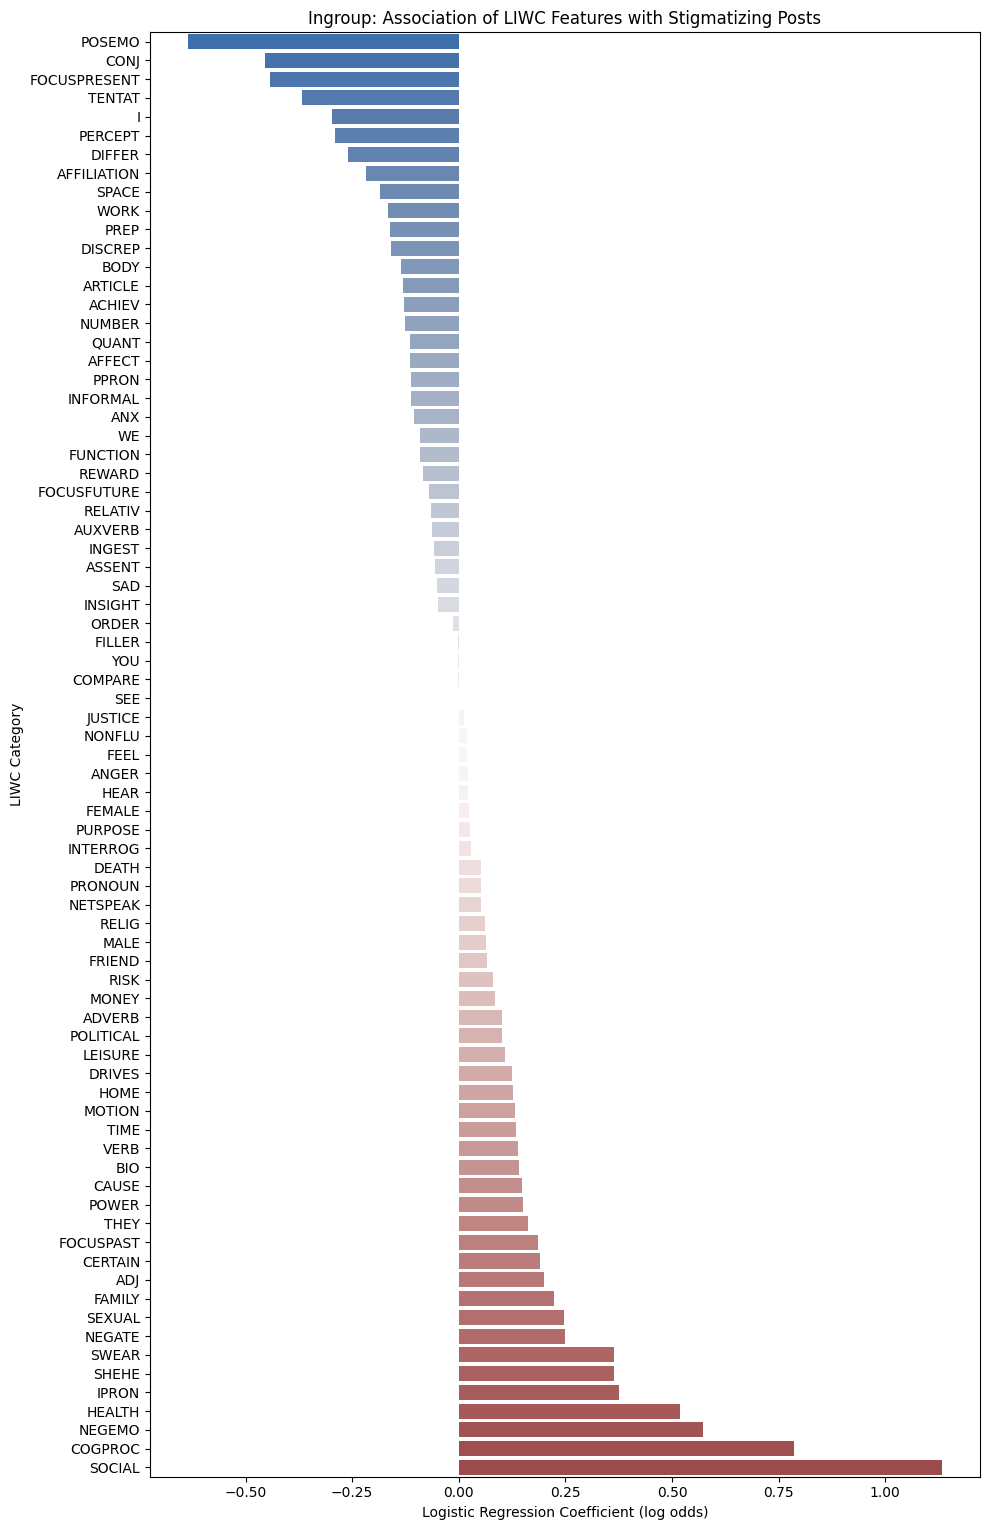

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot logistic coefficients (excluding intercept)
plot_df = logit_results[logit_results["LIWC_feature"] != "const"].copy()
results_sorted = plot_df.sort_values("coef_logit")

plt.figure(figsize=(10, max(6, len(results_sorted) * 0.2)))
sns.barplot(
    y="LIWC_feature",
    x="coef_logit",
    data=results_sorted,
    palette="vlag",
)
plt.xlabel("Logistic Regression Coefficient (log odds)")
plt.ylabel("LIWC Category")
plt.title("Ingroup: Association of LIWC Features with Stigmatizing Posts")
plt.tight_layout()
plt.show()

/var/folders/ns/p84w9tpx2y35z79cb9pml23m0000gn/T/ipykernel_19674/3156436036.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


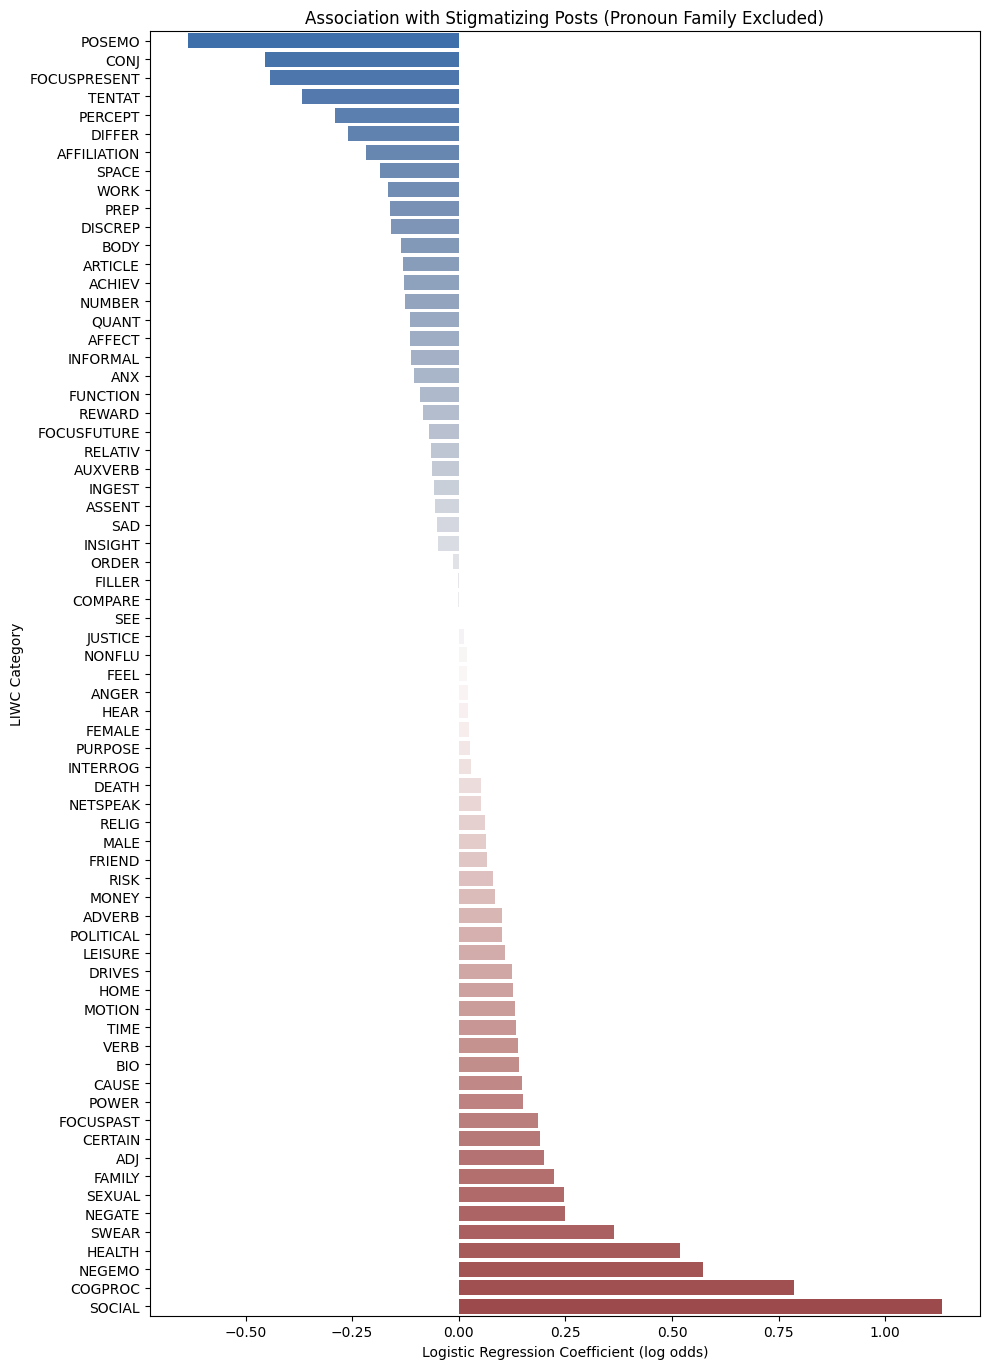

In [10]:
# --- Secondary plot: exclude pronoun-family categories for readability ---
# Filters out: IPRON, I, PPRON, YOU, SHEHE, THEY, WE, PRONOUN

import matplotlib.pyplot as plt
import seaborn as sns

exclude_pronoun_family = {"IPRON", "I", "PPRON", "YOU", "SHEHE", "THEY", "WE", "PRONOUN"}

plot_df_no_pron = logit_results[logit_results["LIWC_feature"] != "const"].copy()
plot_df_no_pron = plot_df_no_pron[
    ~plot_df_no_pron["LIWC_feature"].str.upper().isin(exclude_pronoun_family)
].copy()

# Uses the same metric currently stored in logit_results (coef_logit).
results_no_pron_sorted = plot_df_no_pron.sort_values("coef_logit")

plt.figure(figsize=(10, max(6, len(results_no_pron_sorted) * 0.2)))
sns.barplot(
    y="LIWC_feature",
    x="coef_logit",
    data=results_no_pron_sorted,
    palette="vlag",
)
plt.xlabel("Logistic Regression Coefficient (log odds)")
plt.ylabel("LIWC Category")
plt.title("Association with Stigmatizing Posts (Pronoun Family Excluded)")
plt.tight_layout()
plt.show()